In [1]:
!pip install --upgrade pip setuptools wheel
!pip uninstall -y transformers huggingface_hub peft
!pip install transformers==4.40.0 datasets jiwer Pillow tqdm huggingface_hub==0.25.1 peft==0.11.1
print('Installation complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.1 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.4.1
Uninstalling huggingface_hub-1.4.1:
  Successfully uninstalled huggingface_hub-1.4.1
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
   ━━━━━━━━━━━

In [2]:
import os

# Base paths for Kaggle
BASE_DIR = '/kaggle/input/datasets/sachinkhote/processed-prescription-data/'
MODEL_SAVE = '/kaggle/working/trocr_prescription_model'

train_csv = os.path.join(BASE_DIR, 'train.csv')
val_csv   = os.path.join(BASE_DIR, 'val.csv')
test_csv  = os.path.join(BASE_DIR, 'test.csv')

print("Checking CSV files:")
for name, path in [('train.csv', train_csv), ('val.csv', val_csv), ('test.csv', test_csv)]:
    print(f'  {name}: {"FOUND" if os.path.exists(path) else "NOT FOUND"}')

os.makedirs(MODEL_SAVE, exist_ok=True)
print(f'Model will save locally to: {MODEL_SAVE}')

Checking CSV files:
  train.csv: FOUND
  val.csv: FOUND
  test.csv: FOUND
Model will save locally to: /kaggle/working/trocr_prescription_model


In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator
from jiwer import wer as compute_wer
import tqdm

MODEL_CHECKPOINT = 'microsoft/trocr-base-handwritten'
MAX_LENGTH    = 16
BATCH_SIZE    = 8     # Reduced for T4 GPU memory
EPOCHS        = 15
LEARNING_RATE = 5e-5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

2026-05-23 03:20:19.753191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779506419.923946      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779506419.977568      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779506420.397471      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779506420.397506      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779506420.397509      23 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4


In [4]:
print('Loading TrOCR model (~400MB, please wait)...')
processor = TrOCRProcessor.from_pretrained(MODEL_CHECKPOINT)
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_CHECKPOINT).to(device)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.config.max_length             = MAX_LENGTH
model.config.no_repeat_ngram_size   = 3
model.config.early_stopping         = False  # Fixed for num_beams=1
model.config.num_beams              = 1

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded. Parameters: {total_params:,}')

Loading TrOCR model (~400MB, please wait)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Parameters: 333,921,792


In [5]:
class PrescriptionDataset(Dataset):
    def __init__(self, csv_path, processor, max_length=32):
        self.df         = pd.read_csv(csv_path)
        self.processor  = processor
        self.max_length = max_length
        path_col        = 'processed_path' if 'processed_path' in self.df.columns else 'filepath'
        
        # Translate Windows paths to Kaggle paths
        IMAGE_FOLDER_NAME = 'images' 
        self.df['filename'] = self.df[path_col].apply(lambda x: str(x).replace('\\', '/').split('/')[-1])
        self.df['kaggle_path'] = self.df['filename'].apply(lambda x: os.path.join(BASE_DIR, IMAGE_FOLDER_NAME, x))
        
        self.df = self.df[self.df['kaggle_path'].notna() & self.df['label'].notna()].copy()
        print(f'  Loaded {len(self.df)} samples from {csv_path}')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['kaggle_path']).convert('RGB')
        except Exception as e:
            print(f"FAILED TO LOAD: {row['kaggle_path']} - {e}")
            img = Image.new('RGB', (128, 32), color=255)

        pixel_values = self.processor(img, return_tensors='pt').pixel_values.squeeze(0)

        with self.processor.tokenizer.as_target_tokenizer():
            labels = self.processor.tokenizer(
                str(row['label']).strip(),
                padding='max_length', max_length=self.max_length,
                truncation=True, return_tensors='pt'
            ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {'pixel_values': pixel_values, 'labels': labels}

print('Building datasets...')
train_dataset = PrescriptionDataset(train_csv, processor, MAX_LENGTH)
val_dataset   = PrescriptionDataset(val_csv,   processor, MAX_LENGTH)
test_dataset  = PrescriptionDataset(test_csv,  processor, MAX_LENGTH)

Building datasets...
  Loaded 12480 samples from /kaggle/input/datasets/sachinkhote/processed-prescription-data/train.csv
  Loaded 780 samples from /kaggle/input/datasets/sachinkhote/processed-prescription-data/val.csv
  Loaded 780 samples from /kaggle/input/datasets/sachinkhote/processed-prescription-data/test.csv


In [6]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids   = pred.predictions
    pred_str   = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str  = processor.batch_decode(labels_ids, skip_special_tokens=True)
    wer_score  = compute_wer(label_str, pred_str)
    correct    = sum(sum(1 for p,l in zip(ps,ls) if p==l) for ps,ls in zip(pred_str,label_str))
    total      = sum(max(len(ps),len(ls)) for ps,ls in zip(pred_str,label_str))
    char_acc   = correct/total if total > 0 else 0
    return {'wer': round(wer_score,4), 'char_acc': round(char_acc,4)}

print('Metrics defined: WER + Character Accuracy')

Metrics defined: WER + Character Accuracy


In [7]:
training_args = Seq2SeqTrainingArguments(
    output_dir='/kaggle/working/trocr_checkpoints',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='char_acc',
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=MAX_LENGTH,
    generation_num_beams=1,
    logging_steps=100,
    report_to='none',
    save_total_limit=2,
    fp16=True,  # Enables Mixed Precision for T4 GPU
)

In [8]:
import os

print("Searching Kaggle for your images...")
image_found = 0

# Walk through all directories in Kaggle input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.png') or filename.endswith('.jpg'):
            print(f"I found an image here: {os.path.join(dirname, filename)}")
            image_found += 1
            if image_found >= 3: # Just print the first 3 to keep it clean
                break
    if image_found >= 3:
        break

if image_found == 0:
    print("WARNING: I couldn't find ANY .png or .jpg files in your input directory!")

Searching Kaggle for your images...
I found an image here: /kaggle/input/datasets/sachinkhote/processed-prescription-data/images/img_000947.png
I found an image here: /kaggle/input/datasets/sachinkhote/processed-prescription-data/images/aug_001123_2.png
I found an image here: /kaggle/input/datasets/sachinkhote/processed-prescription-data/images/aug_001026_2.png


In [9]:
trainer = Seq2SeqTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    compute_metrics=compute_metrics, data_collator=default_data_collator,
)

print('Starting TrOCR fine-tuning...')
print('Expected time: 3-5 hours on T4 GPU')
print('CRNN baseline char_acc = 0.2128 — watch this improve!')
print('-'*50)

train_result = trainer.train()
print(f'Training complete! Loss: {train_result.metrics["train_loss"]:.4f}')

Starting TrOCR fine-tuning...
Expected time: 3-5 hours on T4 GPU
CRNN baseline char_acc = 0.2128 — watch this improve!
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Wer,Char Acc
1,0.166800,0.142804,0.098700,0.928400
2,0.071500,0.117349,0.055700,0.956200
3,0.035700,0.084716,0.049400,0.958500
4,0.012400,0.093818,0.026600,0.977400
5,0.009700,0.099604,0.029100,0.975400
6,0.023000,0.083119,0.017700,0.984600
7,0.003000,0.163754,0.041800,0.968300
8,0.018700,0.098428,0.022800,0.979600
9,0.000000,0.088211,0.020300,0.982700
10,0.000000,0.119827,0.027800,0.977600


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1256: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'no_repeat_ngram_size': 3}
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You

Training complete! Loss: 0.0552


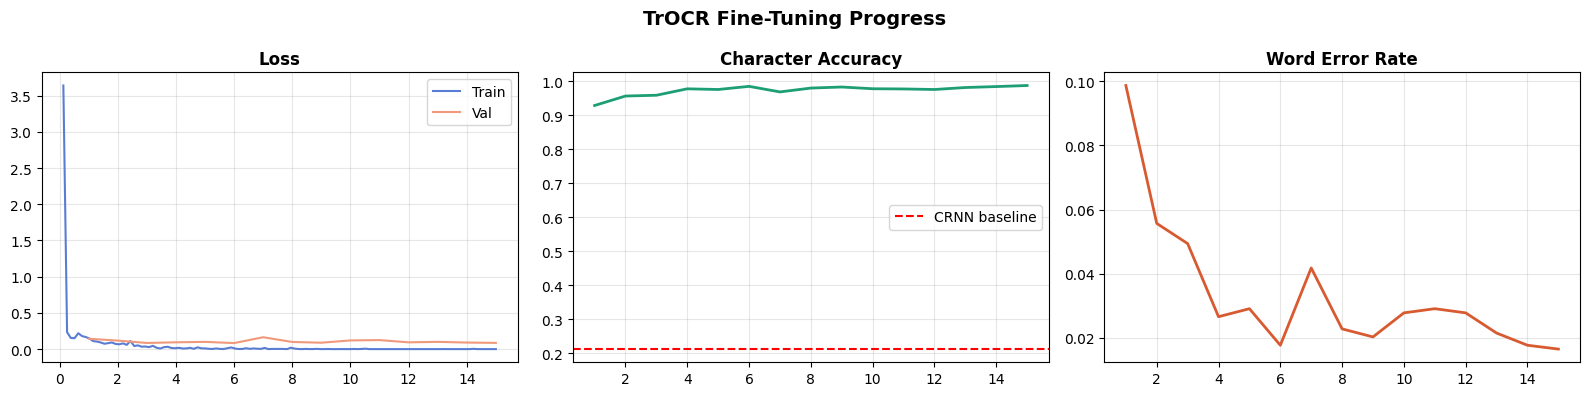

Saved to Kaggle Output — screenshot for your report!


In [10]:
log_history  = trainer.state.log_history
train_losses = [(x['epoch'],x['loss']) for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs    = [(x['epoch'],x['eval_loss'],x.get('eval_char_acc',0),x.get('eval_wer',0)) for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot([x[0] for x in train_losses],[x[1] for x in train_losses],label='Train',color='#5A7DD4')
axes[0].plot([x[0] for x in eval_logs],[x[1] for x in eval_logs],label='Val',color='#F0997B')
axes[0].set_title('Loss',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([x[0] for x in eval_logs],[x[2] for x in eval_logs],color='#1D9E75',linewidth=2)
axes[1].axhline(y=0.2128,color='red',linestyle='--',label='CRNN baseline')
axes[1].set_title('Character Accuracy',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot([x[0] for x in eval_logs],[x[3] for x in eval_logs],color='#D85A30',linewidth=2)
axes[2].set_title('Word Error Rate',fontweight='bold'); axes[2].grid(alpha=0.3)

plt.suptitle('TrOCR Fine-Tuning Progress',fontsize=14,fontweight='bold')
plt.tight_layout()

# Fixed path for Kaggle
plt.savefig('/kaggle/working/trocr_training_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved to Kaggle Output — screenshot for your report!')

In [11]:
print('Evaluating on test set...')
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm.tqdm(DataLoader(test_dataset, batch_size=BATCH_SIZE), desc='Testing'):
        ids = model.generate(batch['pixel_values'].to(device), max_length=MAX_LENGTH, num_beams=1)
        all_preds.extend(processor.batch_decode(ids, skip_special_tokens=True))
        lids = batch['labels']; lids[lids==-100] = processor.tokenizer.pad_token_id
        all_labels.extend(processor.batch_decode(lids, skip_special_tokens=True))

final_wer      = compute_wer(all_labels, all_preds)
correct_chars  = sum(sum(1 for p,l in zip(ps,ls) if p==l) for ps,ls in zip(all_preds,all_labels))
total_chars    = sum(max(len(ps),len(ls)) for ps,ls in zip(all_preds,all_labels))
char_acc       = correct_chars/total_chars if total_chars>0 else 0
word_acc       = sum(1 for p,l in zip(all_preds,all_labels) if p==l)/len(all_labels)

print('='*50)
print('  FINAL TEST RESULTS')
print('='*50)
print(f'  Raw Character Accuracy : {char_acc*100:.2f}%')
print(f'  Word Accuracy          : {word_acc*100:.2f}%')
print(f'  Word Error Rate        : {final_wer:.4f}')
print('='*50)

print(f'Saving model to {MODEL_SAVE}...')
model.save_pretrained(MODEL_SAVE)
processor.save_pretrained(MODEL_SAVE)

with open(f'{MODEL_SAVE}/results.txt','w') as f:
    f.write(f'Raw Character Accuracy: {char_acc*100:.2f}%\n')
    f.write(f'Word Accuracy: {word_acc*100:.2f}%\n')
    f.write(f'WER: {final_wer:.4f}\n')

print('Model saved perfectly!')

Evaluating on test set...


Testing:   0%|          | 0/98 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Testing: 100%|██████████| 98/98 [01:21<00:00,  1.20it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'no_repeat_ngram_size': 3}


  FINAL TEST RESULTS
  Raw Character Accuracy : 97.42%
  Word Accuracy          : 96.92%
  Word Error Rate        : 0.0316
Saving model to /kaggle/working/trocr_prescription_model...
Model saved perfectly!
